In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
datos = pd.read_csv("Data_for_UCI_named.csv")
datos

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2.930406,9.487627,2.376523,6.187797,3.343416,-0.658054,-1.449106,-1.236256,0.601709,0.779642,0.813512,0.608385,0.023892,unstable
9996,3.392299,1.274827,2.954947,6.894759,4.349512,-1.663661,-0.952437,-1.733414,0.502079,0.567242,0.285880,0.366120,-0.025803,stable
9997,2.364034,2.842030,8.776391,1.008906,4.299976,-1.380719,-0.943884,-1.975373,0.487838,0.986505,0.149286,0.145984,-0.031810,stable
9998,9.631511,3.994398,2.757071,7.821347,2.514755,-0.966330,-0.649915,-0.898510,0.365246,0.587558,0.889118,0.818391,0.037789,unstable


In [3]:
# Veo el resumen de las columnas y si hay vacíos
print("Resumen de la tabla")
datos.info()

# Cuento cuantos escenarios son estables (stable) y cuantos inestables (unstable)
print("Conteo de estabilidad")
datos['stabf'].value_counts()

Resumen de la tabla
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB
Conteo de estabilidad


stabf
unstable    6380
stable      3620
Name: count, dtype: int64

C:\Users\samir\AppData\Local\Temp\ipykernel_20676\2084886127.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=datos, x="stabf", palette="Set2")


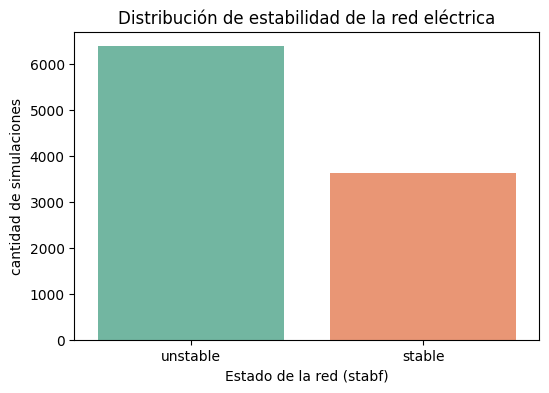

In [4]:
#Visualización
#crear lienzo en blanco para el gráfico
plt.figure(figsize=(6, 4))
#Dibujar un gráfico de barras contando los estables e intestables
sns.countplot(data=datos, x="stabf", palette="Set2")

plt.title("Distribución de estabilidad de la red eléctrica")
plt.xlabel("Estado de la red (stabf)")
plt.ylabel("cantidad de simulaciones")

plt.show()

In [5]:
#Feature Engineering
#Al principio usé la potencia pero al parecer, contraria a la lógica física este dataset no usa la potencia para determinar estabildiad eléctrica
datos["tau_promedio"] = (datos["tau1"] + datos["tau2"] + datos["tau3"] + datos["tau4"]) / 4
datos["g_promedio"] = (datos["g1"] + datos["g2"] + datos["g3"] + datos["g4"]) / 4

display(datos[["tau_promedio", "g_promedio"]].head())

,tau_promedio,g_promedio
0,6.050181,0.838878
1,4.655880,0.654938
2,5.520283,0.469757
3,3.803305,0.678763
4,6.386054,0.682607


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Primero separo las pistas (X) de las respuestas (y)
#Quito "stabf" (la respuesta) y "stab"
X = datos.drop(columns=["stabf", "stab"])
y = datos["stabf"]

#Ahora divido 80% para estudio y 20% para prueba
#random_state=42 asegura que el corte siempre sea el mismo si vuelvo a correr el código
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Escalar los datos
scaler = StandardScaler()

#El modelo "aprende" la escala con los datos de estudio y los transforma
X_train_escalado = scaler.fit_transform(X_train)

#Aplicamos la misma regla a los datos de prueba
X_test_escalado = scaler.transform(X_test)

print("Tenemos", X_train_escalado.shape[0],"escenarios para estudiar")
print("y", X_test_escalado.shape[0], "escenarios ocultos para la prueba final")


Tenemos 8000 escenarios para estudiar
y 2000 escenarios ocultos para la prueba final


In [7]:
#Feature Selection (información mutua)
from sklearn.feature_selection import mutual_info_classif

#Calcular la importancia de cada feature
puntajes_informacion = mutual_info_classif(X_train_escalado, y_train, random_state=42)

#Tabla para visualizar el ranking de importancia
tabla_importancia = pd.DataFrame({
    "variable": X.columns,
    "Información aportada": puntajes_informacion
}).sort_values(by="Información aportada", ascending=False)

display(tabla_importancia)

,variable,Información aportada
12,tau_promedio,0.126787
13,g_promedio,0.109508
1,tau2,0.041613
3,tau4,0.041420
2,tau3,0.038322
0,tau1,0.035925
9,g2,0.030275
10,g3,0.024215
8,g1,0.022514
11,g4,0.020525


Por qué las potencias me dan 0? significa que la estabilidad no depende de la potencia sino del tiempo y la carga? o quizas en el dataset las potencias son vairables de control que se ajustan automatico por lo que no determina el colapso sino que este viene de tau y g.
No sé si es de dataset o que porque en redes la potencia si está ligada, tal vez justo en este dataset la estabilidad no depende de la potencia. 
Significa eso entonces que la pista que le dí está mal? 
Debería descartar info para eliminar ruido? 
Revisar.

In [8]:
#Filtrar ruido

#Guardar los nombres de las variables que sacaron más de 0
columnas_utiles = tabla_importancia[tabla_importancia["Información aportada"] > 0]["variable"].tolist()

print("Nos quedamos solo con:", columnas_utiles)



Nos quedamos solo con: ['tau_promedio', 'g_promedio', 'tau2', 'tau4', 'tau3', 'tau1', 'g2', 'g3', 'g1', 'g4']


In [9]:
#Buscar en qué posición númerica están esas columnas útiles
indices_utiles = [X.columns.get_loc(col) for col in columnas_utiles]

#Recortamos nuestras matrices de estudio y prueba para quedarnos solo con las columnas útiles
X_train_filtrado = X_train_escalado[:, indices_utiles]
X_test_filtrado = X_test_escalado[:, indices_utiles]

print(f"Pasamos de {X_train_escalado.shape[1]} a {X_train_filtrado.shape[1]} columnas.")

Pasamos de 14 a 10 columnas.


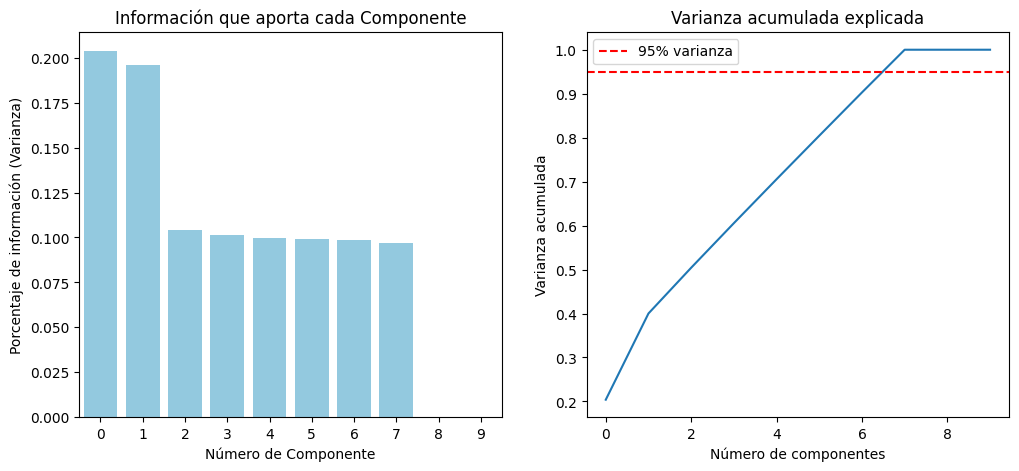

In [10]:
#PCA
from sklearn.decomposition import PCA
import numpy as np

#PCA se entrena con los datos ya filtrados
pca = PCA()
pca.fit(X_train_filtrado)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(
    x=np.arange(len(pca.explained_variance_ratio_)), 
    y=pca.explained_variance_ratio_, 
    color="skyblue"
)
plt.title("Información que aporta cada Componente")
plt.xlabel("Número de Componente")
plt.ylabel("Porcentaje de información (Varianza)")

plt.subplot(1, 2, 2)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.axhline(y=0.95, color="Red", linestyle="--", label="95% varianza")
plt.title("Varianza acumulada explicada")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.legend()
plt.show()

In [11]:
#Compresión final
pca_final = PCA(n_components=0.95)
X_train_pca = pca_final.fit_transform(X_train_filtrado)
X_test_pca = pca_final.transform(X_test_filtrado)

In [24]:
#Usando Regresión Logistica
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score
from sklearn.model_selection import cross_val_score

#Llamo al modelo
modelo_logistico = LogisticRegression()

#Lo hago estudiar los 8.000 datos
modelo_logistico.fit(X_train_pca, y_train)

#Validación cruzada (control de Overfitting)
#Tomo 5 pruebas distintas a los datos de estudio
notas_cv_log = cross_val_score(modelo_logistico, X_train_pca, y_train, cv=5)
print(f"Validación cruzada (5 pruebas): {notas_cv_log.mean()*100:.2f}% de exactitud promedio")

#Testeo, le pido que adivine la estabilidad de los 2.000 datos ocultos
predicciones_log = modelo_logistico.predict(X_test_pca)
probabilidades_log = modelo_logistico.predict_proba(X_test_pca)[:,1] #esto es necesario para ROC-AUC

#Comparo sus adivinanzas con las respuestas reales
precision_log = accuracy_score(y_test, predicciones_log)
print(f"El modelo predijo la estabilidad con un {precision_log * 100:.2f}% de exactitud.\n")

#Reporte completo de métricas
print("\nReporte de clasisificación detallado:")
print(classification_report(y_test, predicciones_log))

#ROC-AUC
roc_auc_log = roc_auc_score(y_test, probabilidades_log)
print(f"Puntaje ROC.AUC: {roc_auc_log:.4f}\n")


Validación cruzada (5 pruebas): 81.46% de exactitud promedio
El modelo predijo la estabilidad con un 81.75% de exactitud.


Reporte de clasisificación detallado:
              precision    recall  f1-score   support

      stable       0.74      0.72      0.73       693
    unstable       0.86      0.87      0.86      1307

    accuracy                           0.82      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.82      0.82      0.82      2000

Puntaje ROC.AUC: 0.8903



<Figure size 600x400 with 0 Axes>

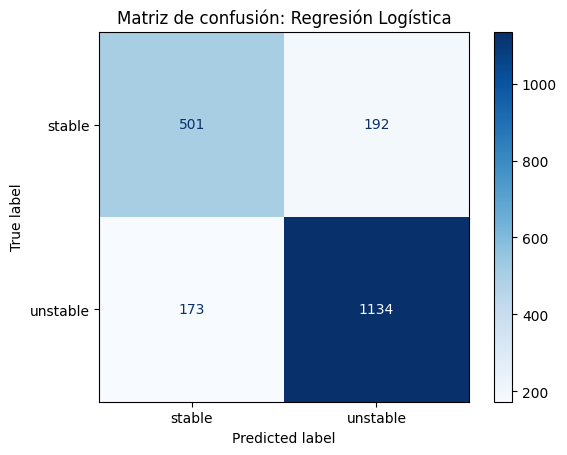

In [13]:
#Matriz de confusión con los aciertos y errores
matriz_log = confusion_matrix(y_test, predicciones_log)

grafico_log = ConfusionMatrixDisplay(confusion_matrix=matriz_log, display_labels=modelo_logistico.classes_)

plt.figure(figsize=(6,4))
grafico_log.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión: Regresión Logística")
plt.show()

In [29]:
#Ahora usaré KNN
from sklearn.neighbors import KNeighborsClassifier

#El modelo mirará los 5 vecinos más cercanos
modelo_knn = KNeighborsClassifier(n_neighbors=5)
modelo_knn.fit(X_train_pca, y_train)

#Validación cruzada
notas_cv_knn = cross_val_score(modelo_knn, X_train_pca, y_train, cv=5)
print(f"Validación cruzarada (5 pruebas): {notas_cv_knn.mean()*100:.2f}% de exactitud promedio")

#testeo
predicciones_knn = modelo_knn.predict(X_test_pca)
probabilidades_knn = modelo_knn.predict_proba(X_test_pca)[:,1]

#metricas
precision_knn = accuracy_score(y_test, predicciones_knn)
print(f"El modelo predijo la estabilidad con un {precision_knn * 100:.2f}% de exactitud.\n")

print(f"\nReporte de clasificación detallado:")
print(classification_report(y_test, predicciones_knn))

#ROC-AUC
roc_auc_knn = roc_auc_score(y_test, probabilidades_knn)
print(f"Puntaje ROC-AUC: {roc_auc_knn: .4f}\n")

Validación cruzarada (5 pruebas): 89.57% de exactitud promedio
El modelo predijo la estabilidad con un 89.50% de exactitud.


Reporte de clasificación detallado:
              precision    recall  f1-score   support

      stable       0.87      0.82      0.84       693
    unstable       0.91      0.93      0.92      1307

    accuracy                           0.90      2000
   macro avg       0.89      0.88      0.88      2000
weighted avg       0.89      0.90      0.89      2000

Puntaje ROC-AUC:  0.9617



<Figure size 600x400 with 0 Axes>

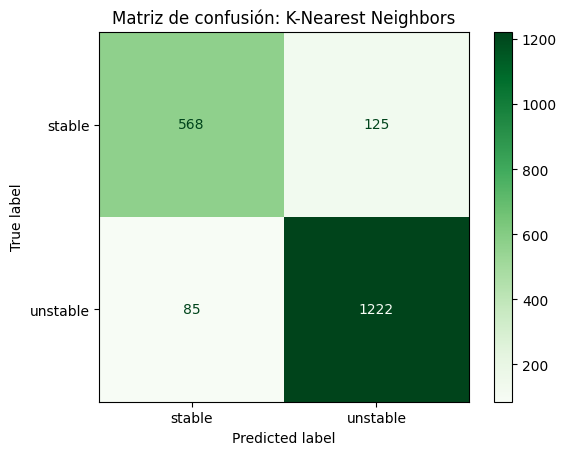

In [27]:
#matriz confusion
matriz_knn = confusion_matrix(y_test, predicciones_knn)
grafico_knn = ConfusionMatrixDisplay(confusion_matrix=matriz_knn, display_labels=modelo_knn.classes_)

plt.figure(figsize=(6, 4))
grafico_knn.plot(cmap="Greens", values_format="d")
plt.title("Matriz de confusión: K-Nearest Neighbors")
plt.show()

In [28]:
print("Comparación de modelos")
print(f"Exactitud Regresión Logística: {precision_log*100:.2f}%")
print(f"Exactitud K-Nearest Neighbors: {precision_knn*100:.2f}%")

Comparación de modelos
Exactitud Regresión Logística: 81.75%
Exactitud K-Nearest Neighbors: 89.50%
